# Origins of replication pre-analysis

From the raw MNase:
- Compute the total occupancy, origin occupancy (small fragments), and non origin occupancy (mostly nucleosomal).
- Compute the peak position of the small origin occupancy location.
- Plot the distribution of the total occupancies and determine a threshold to remove low coverage origins
- Plot the distribution of the proportion of small fragment reads to determine a threshold in which we do not identify an origin footprint.
- Create a column that labels the origins as having called footprints in our dataset.
- Save the constructed dataframe.

In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
from pipeline.precompute_origin_analysis import OriginFootprintAnalysis

window = 1000
origin_analysis = OriginFootprintAnalysis(window_size=window)

In [37]:
origins = origin_analysis.load_origin_reference_dataset()


In [38]:
# Generate all the summary data at once (this may take some time)
small_fragments_data, composite_data = origin_analysis.generate_summary_histogram_data()


Generating summary histogram data for all timepoints and replicates...
Processing replicate 1...
  Processing chromosome 1 (21 origins) - 00:00:00.002
  Processing chromosome 2 (61 origins) - 00:00:03.921
  Processing chromosome 3 (31 origins) - 00:00:37.645
  Processing chromosome 4 (88 origins) - 00:00:45.744
  Processing chromosome 5 (33 origins) - 00:02:53.355
  Processing chromosome 6 (22 origins) - 00:03:08.836
  Processing chromosome 7 (63 origins) - 00:03:14.314
  Processing chromosome 8 (42 origins) - 00:04:11.273
  Processing chromosome 9 (38 origins) - 00:04:27.134
  Processing chromosome 10 (43 origins) - 00:04:38.936
  Processing chromosome 11 (42 origins) - 00:05:00.331
  Processing chromosome 12 (68 origins) - 00:05:20.654
  Processing chromosome 13 (56 origins) - 00:06:41.742
  Processing chromosome 14 (51 origins) - 00:07:19.875
  Processing chromosome 15 (67 origins) - 00:07:45.113
  Processing chromosome 16 (72 origins) - 00:08:44.360
Processing replicate 2...
  Proc

In [51]:
sorted_idx = (origins.footprint_class == 'g1_and_g2_footprint').sort_values(ascending=False).index
sorted_origins = origins.loc[sorted_idx]

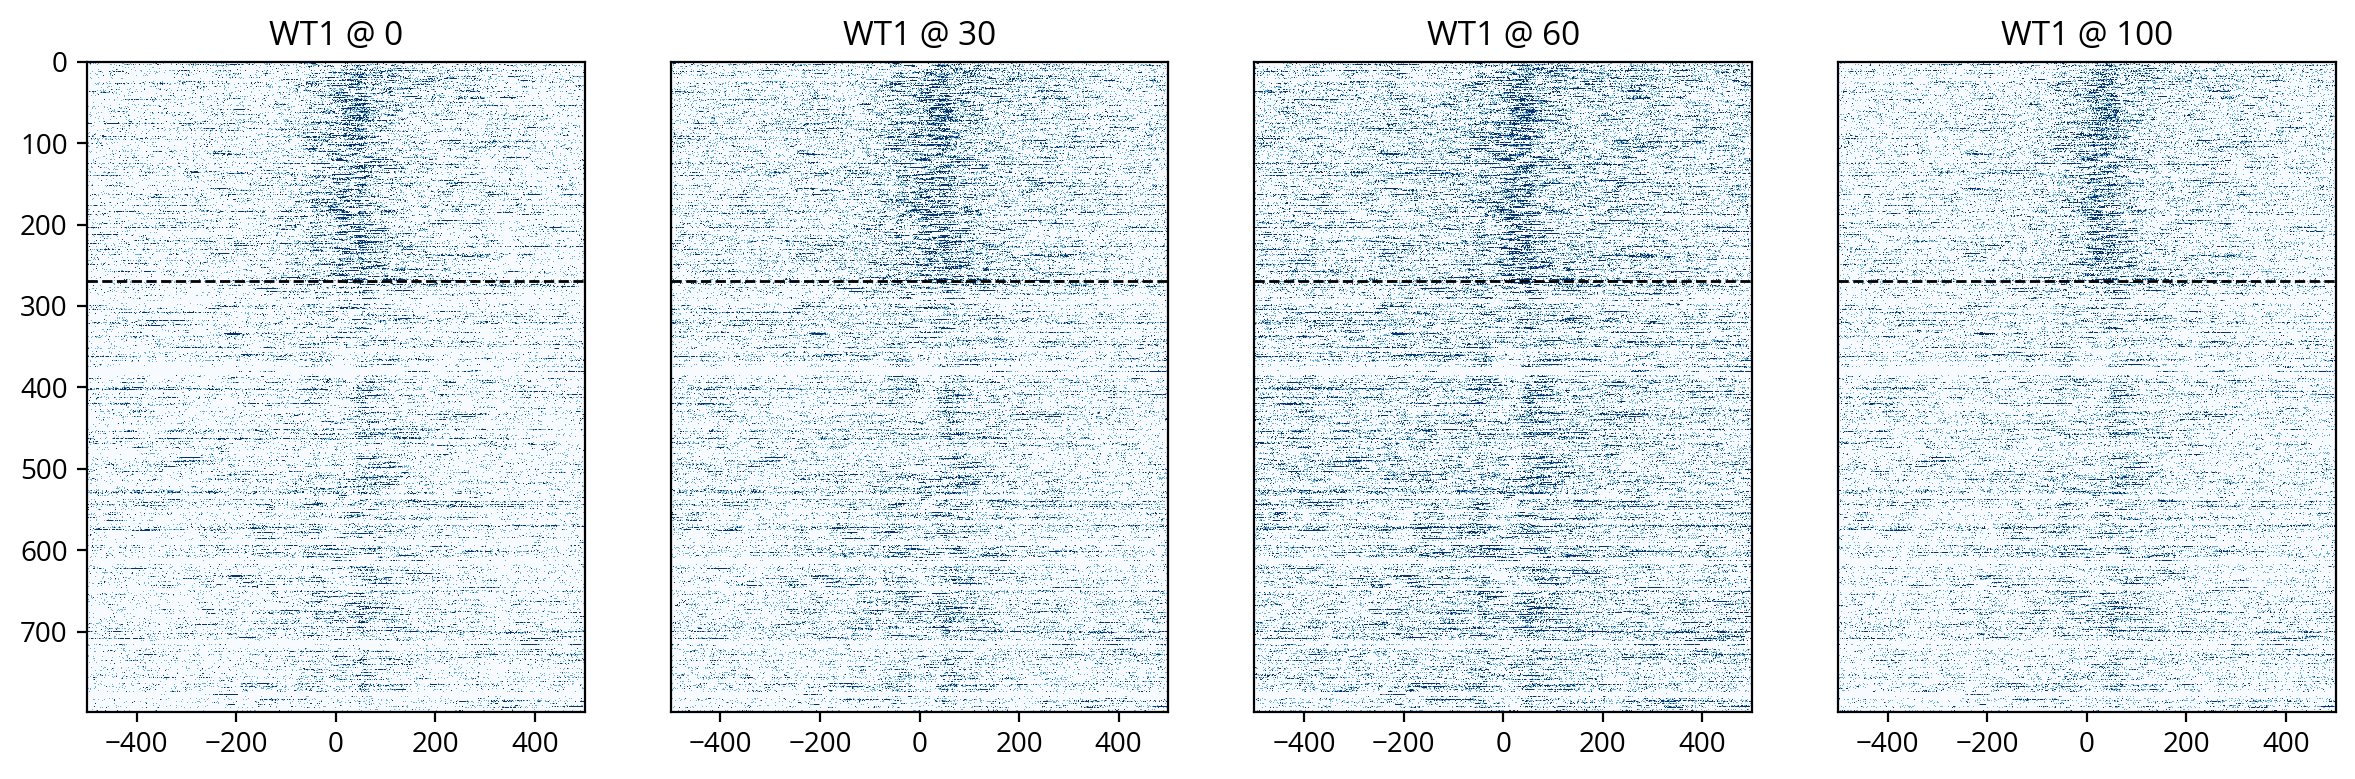

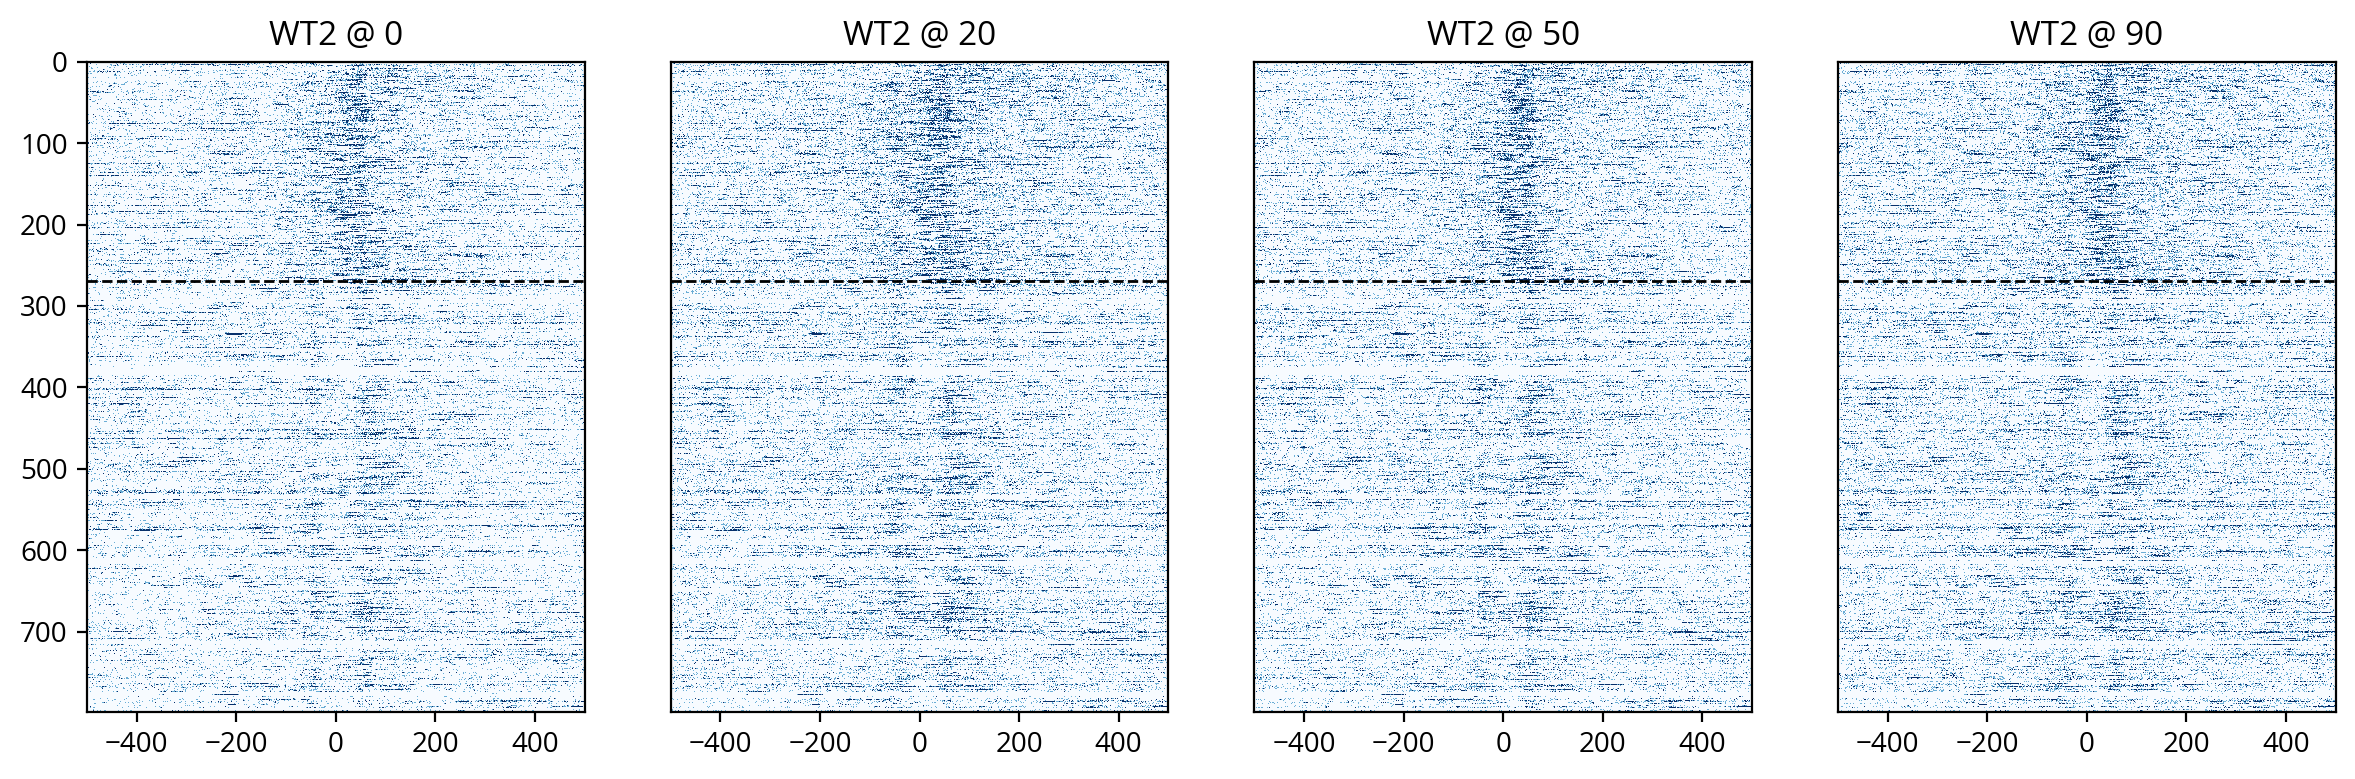

In [57]:
fig = origin_analysis.plot_timecourse_heatmaps(1, [0, 30, 60, 100], sorted_origins)
fig = origin_analysis.plot_timecourse_heatmaps(2, [0, 20, 50, 90], sorted_origins)

In [865]:
# from src.global_config import GlobalConstants
# fig = origin_analysis.plot_timecourse_composites(1, GlobalConstants.CHROM_WT1_TIMEPOINTS)
#fig = origin_analysis.plot_timecourse_composites(2, GlobalConstants.CHROM_WT2_TIMEPOINTS)

# Origins of Replication Deconvolution Analysis - Composite Plots
Evaluation of overall signal for construction of canonical origin. Goal will be to create this canonical origin and correlate with all other origins, to get get a correlation shift score. And characterize the timing of all origins.

In [619]:
from pipeline.deconvolved_origin_analysis import DeconvolvedOriginAnalysis
chromatin_data_path_nodaughter = \
    'output/prototype_pipeline_subset/chromatin_deconvolution_no_daughter/deconvolution_data/'
deconv_origin_analysis_no_daughter = DeconvolvedOriginAnalysis(chromatin_data_path=chromatin_data_path_nodaughter)


In [620]:
dat = deconv_origin_analysis_no_daughter.generate_summary_histogram_data()

Generating summary histogram data for all timepoints...
Initializing data arrays with: 239 origins, 149 timepoints, 100 positions
  Processing chromosome 1 (6 origins) - 00:00:00.221
  Processing chromosome 2 (13 origins) - 00:00:01.221
  Processing chromosome 3 (10 origins) - 00:00:03.130
  Processing chromosome 4 (29 origins) - 00:00:04.622
  Processing chromosome 5 (10 origins) - 00:00:08.933
  Processing chromosome 6 (7 origins) - 00:00:10.425
  Processing chromosome 7 (19 origins) - 00:00:11.442
  Processing chromosome 8 (12 origins) - 00:00:14.261
  Processing chromosome 9 (10 origins) - 00:00:16.145
  Processing chromosome 10 (13 origins) - 00:00:17.636
  Processing chromosome 11 (14 origins) - 00:00:19.665
  Processing chromosome 12 (26 origins) - 00:00:21.794
  Processing chromosome 13 (17 origins) - 00:00:25.690
  Processing chromosome 14 (14 origins) - 00:00:28.419
  Processing chromosome 15 (22 origins) - 00:00:30.513
  Processing chromosome 16 (17 origins) - 00:00:34.054
C

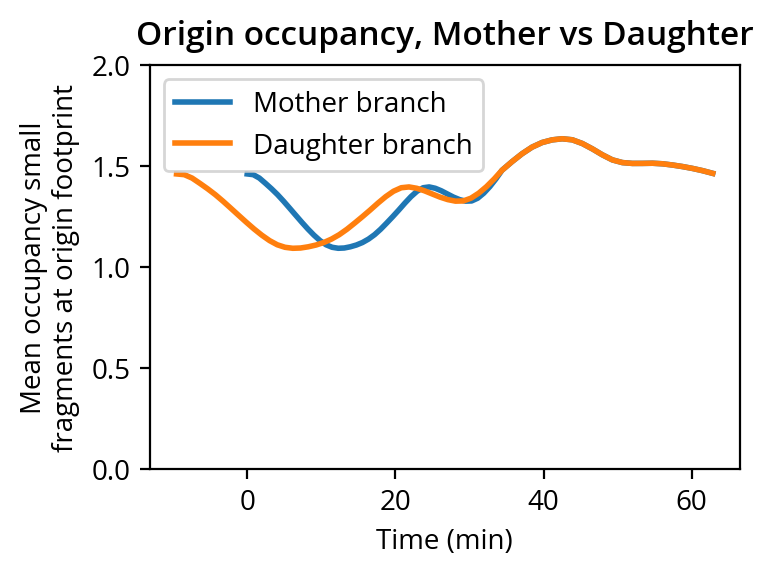

In [784]:
fig = deconv_origin_analysis_no_daughter.plot_small_fragment_occupancy_comparison()

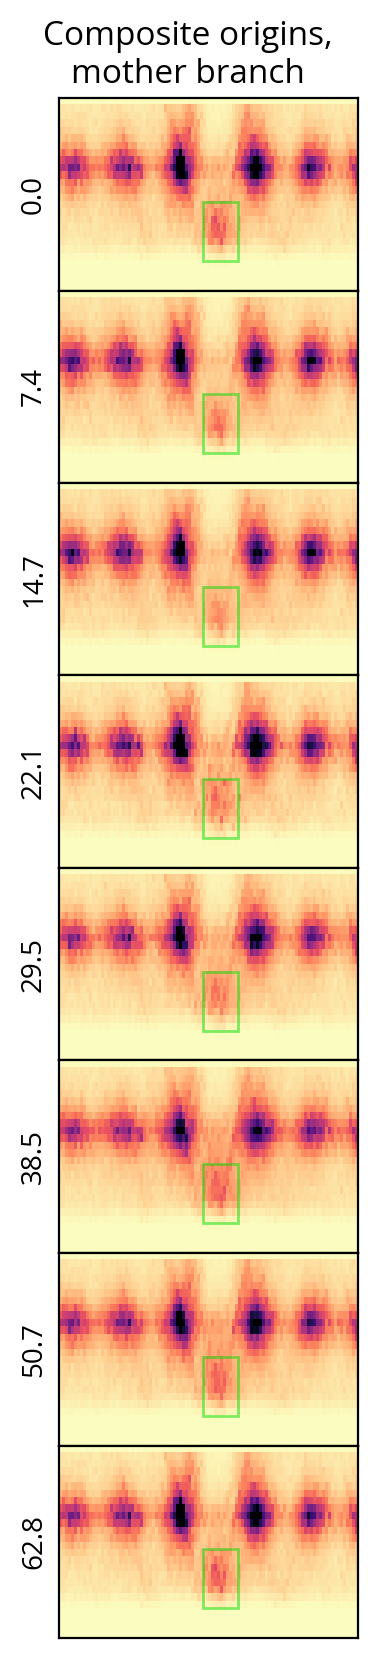

In [863]:
fig = deconv_origin_analysis_no_daughter.plot_composite_histograms('t', max_value=2000,
                                                               highlight_center=True)

In [638]:
from pipeline.origin_consensus_correlation import OriginConsensusCorrelationAnalysis

# Initialize the analysis
consensus_analysis = OriginConsensusCorrelationAnalysis(deconv_origin_analysis_no_daughter)


In [639]:
# Compute correlations with optimal shifts
results = consensus_analysis.compute_correlations(
    shift_range=(-10, 10),
    find_optimal_shift=True,
    time_indices=t_indices
)

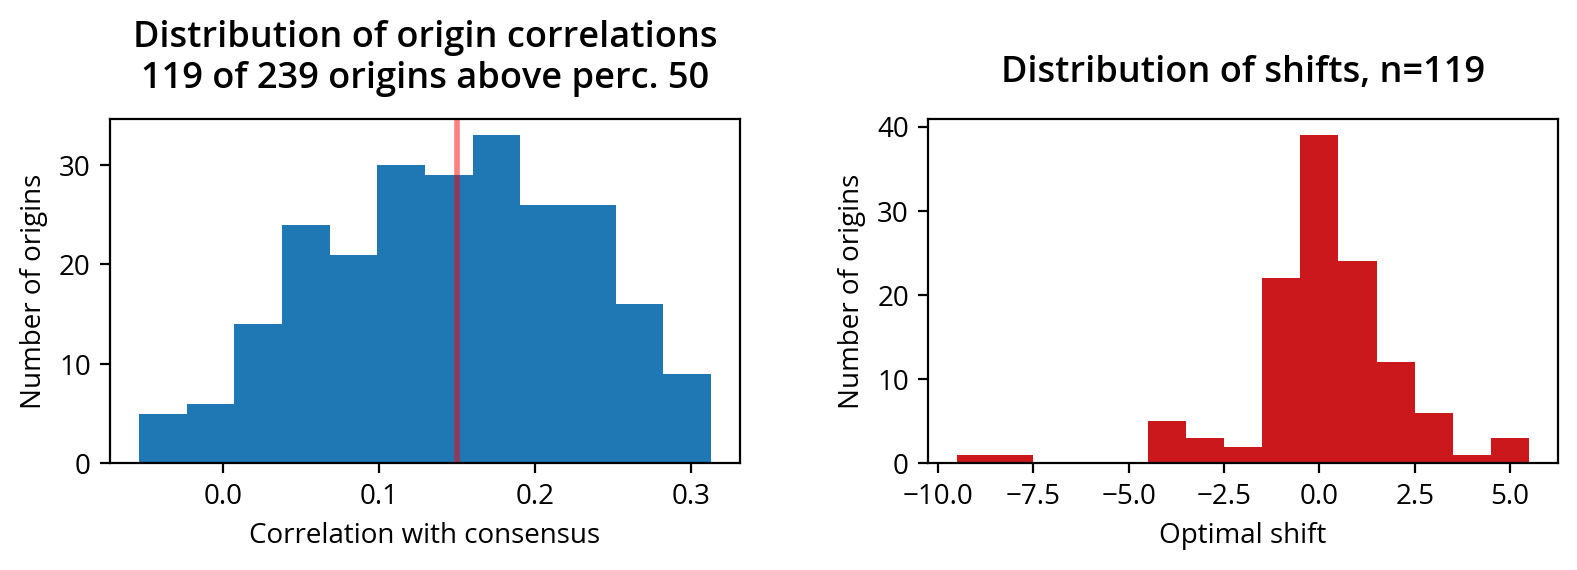

In [883]:
consensus_analysis.plot_distributions()

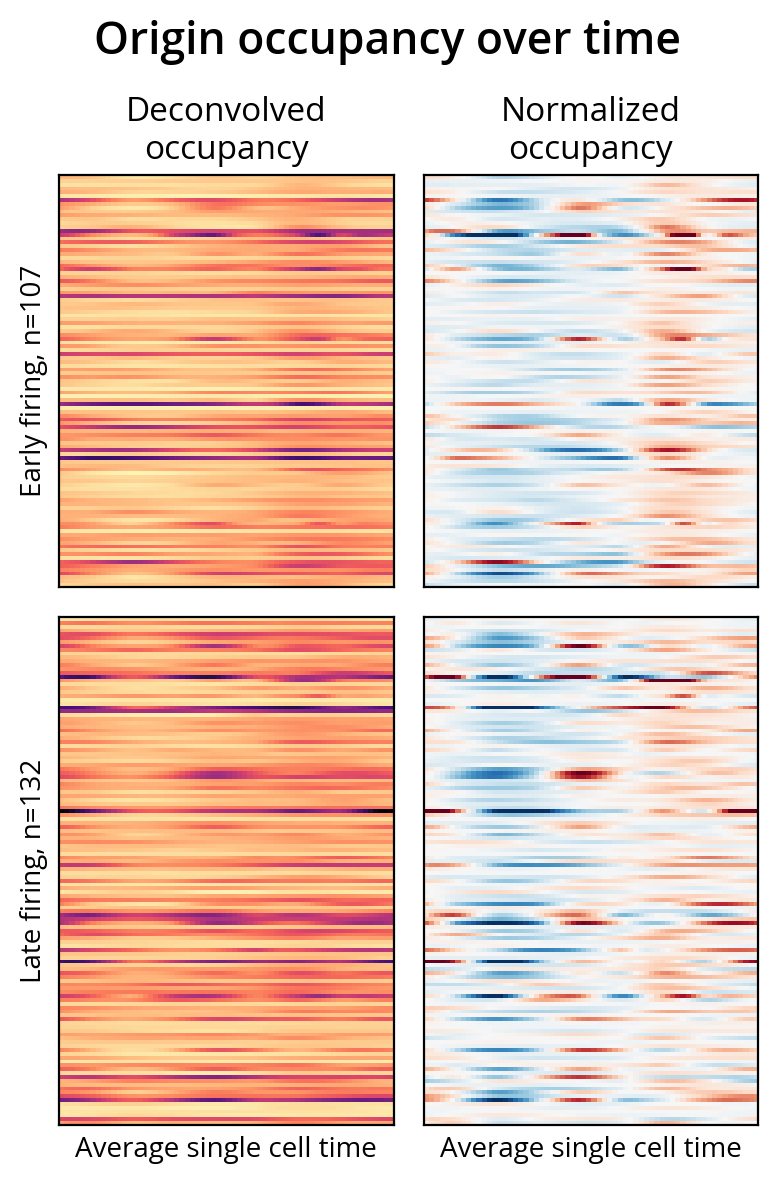

In [844]:
# Visualize the results
consensus_analysis.plot_origin_correlation_heatmap(time_indices=t_indices)


In [893]:
consensus_analysis.retrieve_high_correlation_examples(0.2)

,optimal_shift,correlation,activation_time,ars_name
name,,,,
oridb_42,-3,0.209541,early,ARS209
oridb_498,-2,0.281637,late,ARS1120
oridb_509,-1,0.244837,late,ARS1205
oridb_625,-1,0.261998,early,ARS1330
oridb_330,-1,0.204444,late,ARS735.5
...,...,...,...,...
oridb_361,2,0.230966,late,ARS816
oridb_437,2,0.272286,early,ARS1012
oridb_201,3,0.227488,late,ARS442


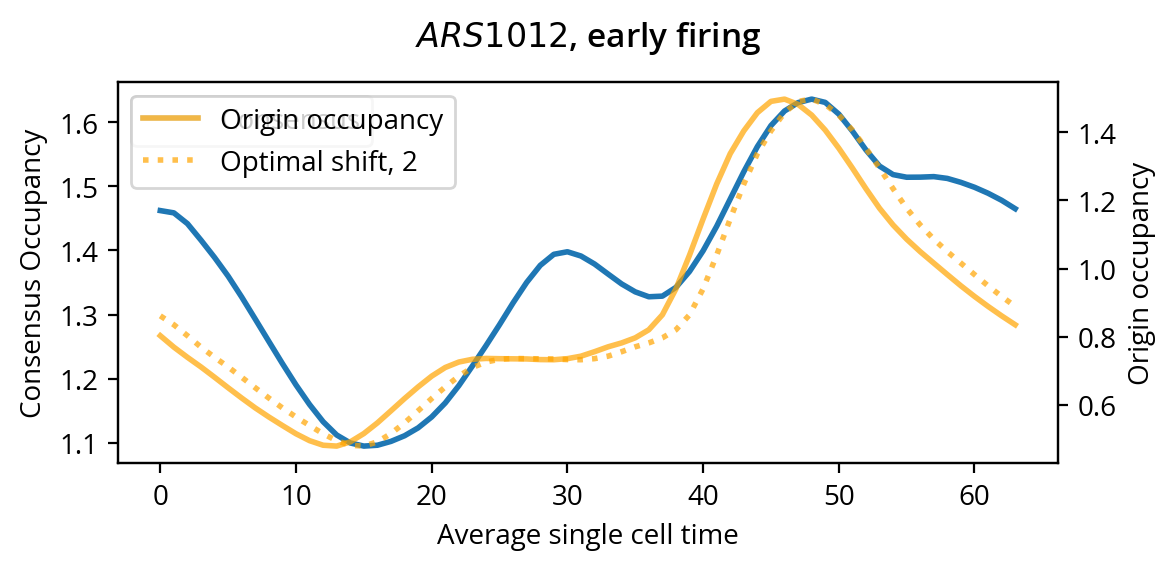

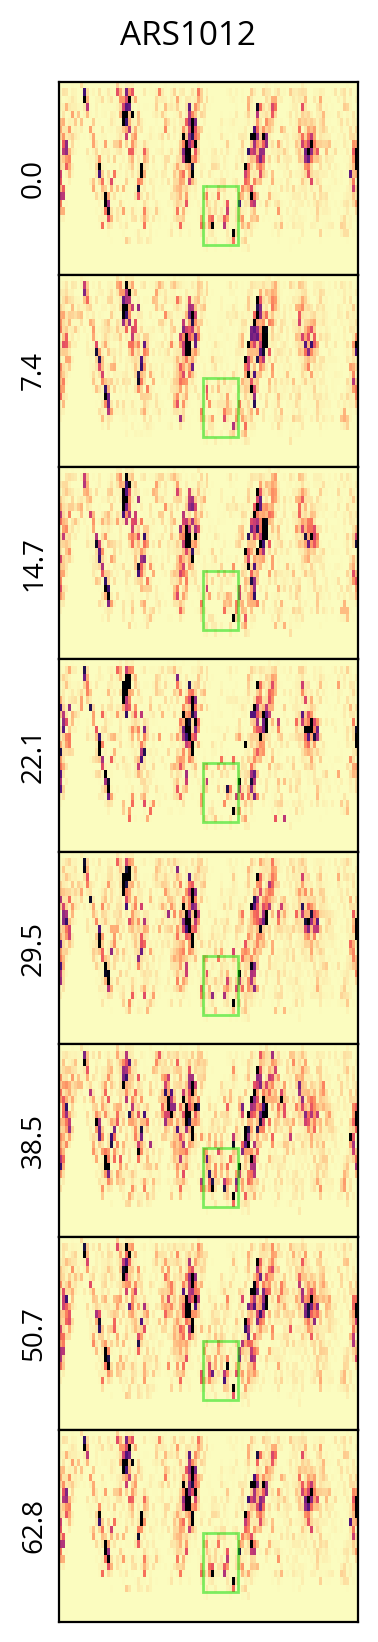

In [902]:
early_origin_id = 'oridb_437'
late_origin_id = 'oridb_498'

consensus_analysis.plot_consensus_vs_origin(origin_id=early_origin_id,
    time_indices=t_indices, title="early firing")
deconv_origin_analysis_no_daughter.plot_origin_heatmap(early_origin_id, 't')

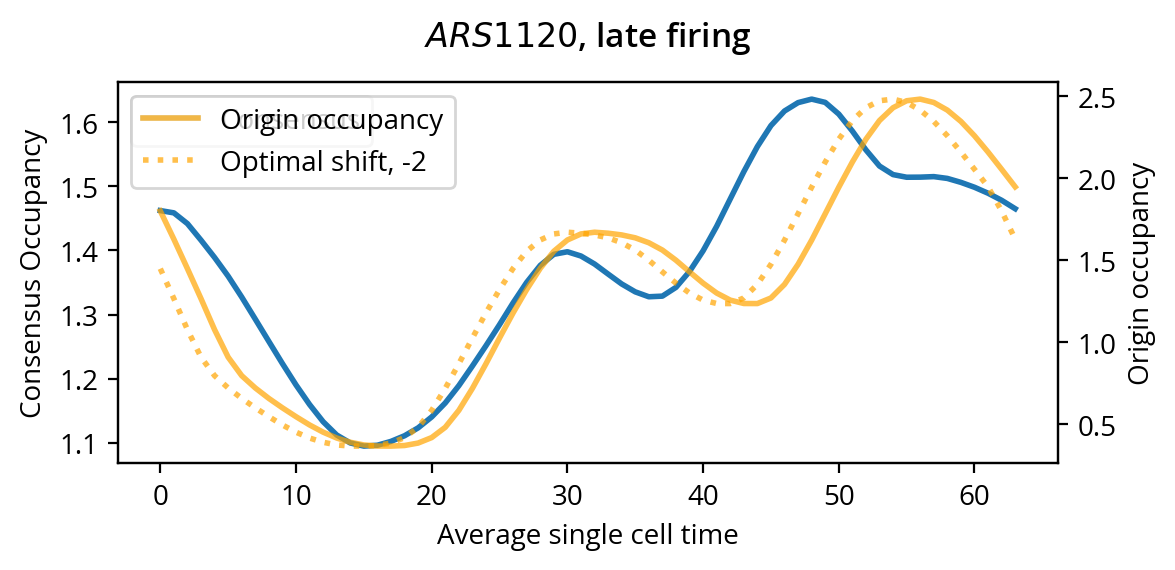

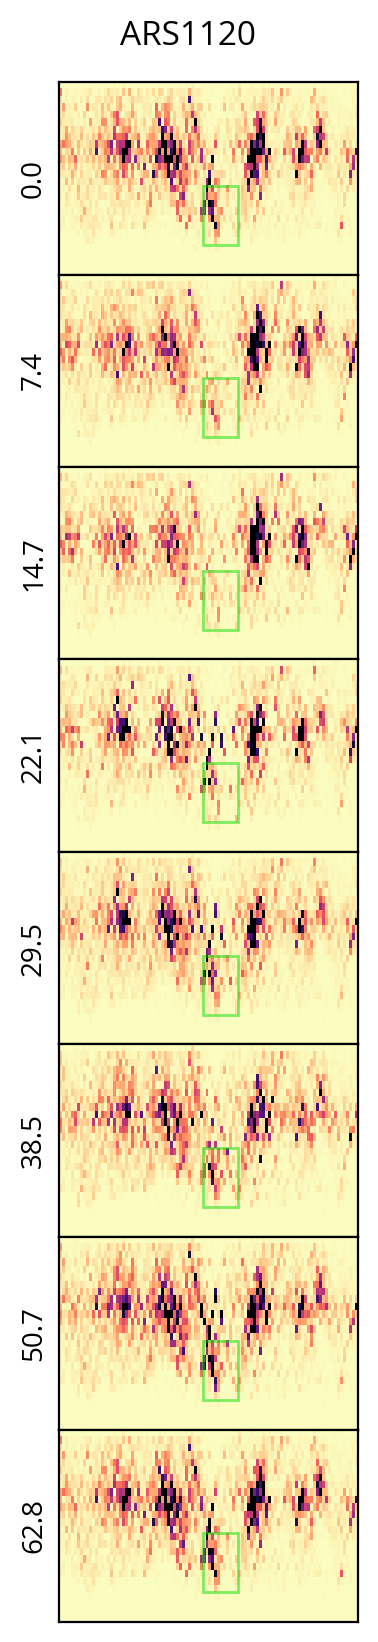

In [898]:
consensus_analysis.plot_consensus_vs_origin(origin_id=late_origin_id, 
    time_indices=t_indices, title="late firing")
deconv_origin_analysis_no_daughter.plot_origin_heatmap(late_origin_id, 't')